# 1) Funcionamento do modelo armazenado em `sparse/0`:

São três arquivos salvos em `File > Export model` ao final de uma reconstrução esparsa no Colmap:
- `cameras.bin`: guarda os parâmetros intrínsecos de cada câmera;
- `images.bin`: guarda os parâmetros extrínsecos de cada ponto de vista (imagem) e uma lista e tuplas (coord2D.x, coord2D.y, point3d_id) para cada ponto 3D observado nesta imagem;
- `points3D.bin`: guarda a lista completa de pontos3D observados na cena, além de uma lista de "rastro" no formato (image_id, point2D_id).

Podendo ser salvos como `.txt` em `File > Export model as text`, possuem as seguintes características:

cameras.txt:

```*.txt
    # Camera list with one line of data per camera:
    #   CAMERA_ID, MODEL, WIDTH, HEIGHT, PARAMS[]
    # Number of cameras: 3
    1 SIMPLE_PINHOLE 3072 2304 2559.81 1536 1152
    2 PINHOLE 3072 2304 2560.56 2560.56 1536 1152
    3 SIMPLE_RADIAL 3072 2304 2559.69 1536 1152 -0.0218531
```

images.txt:

```*.txt
    # Image list with two lines of data per image:
    #   IMAGE_ID, QW, QX, QY, QZ, TX, TY, TZ, CAMERA_ID, NAME
    #   POINTS2D[] as (X, Y, POINT3D_ID)
    # Number of images: 2, mean observations per image: 2
    1 0.851773 0.0165051 0.503764 -0.142941 -0.737434 1.02973 3.74354 1 P1180141.JPG
    2362.39 248.498 58396 1784.7 268.254 59027 1784.7 268.254 -1
    2 0.851773 0.0165051 0.503764 -0.142941 -0.737434 1.02973 3.74354 1 P1180142.JPG
    1190.83 663.957 23056 1258.77 640.354 59070
```

points3D.txt:

```*.txt
    # 3D point list with one line of data per point:
    #   POINT3D_ID, X, Y, Z, R, G, B, ERROR, TRACK[] as (IMAGE_ID, POINT2D_IDX)
    # Number of points: 3, mean track length: 3.3334
    63390 1.67241 0.292931 0.609726 115 121 122 1.33927 16 6542 15 7345 6 6714 14 7227
    63376 2.01848 0.108877 -0.0260841 102 209 250 1.73449 16 6519 15 7322 14 7212 8 3991
    63371 1.71102 0.28566 0.53475 245 251 249 0.612829 118 4140 117 4473
```

Assim, podemos definir algumas classes para armazenar esses dados:

In [2]:
"""
    Taken from https://github.com/graphdeco-inria/gaussian-splatting/blob/main/scene/colmap_loader.py
""" 

import numpy as np
import collections
import struct

CameraModel = collections.namedtuple(
    "CameraModel", ["model_id", "model_name", "num_params"])
Camera = collections.namedtuple(
    "Camera", ["id", "model", "width", "height", "params"])
BaseImage = collections.namedtuple(
    "Image", ["id", "qvec", "tvec", "camera_id", "name", "xys", "point3D_ids"])
Point3D = collections.namedtuple(
    "Point3D", ["id", "xyz", "rgb", "error", "image_ids", "point2D_idxs"])
CAMERA_MODELS = {
    CameraModel(model_id=0, model_name="SIMPLE_PINHOLE", num_params=3),
    CameraModel(model_id=1, model_name="PINHOLE", num_params=4),
    CameraModel(model_id=2, model_name="SIMPLE_RADIAL", num_params=4),
    CameraModel(model_id=3, model_name="RADIAL", num_params=5),
    CameraModel(model_id=4, model_name="OPENCV", num_params=8),
    CameraModel(model_id=5, model_name="OPENCV_FISHEYE", num_params=8),
    CameraModel(model_id=6, model_name="FULL_OPENCV", num_params=12),
    CameraModel(model_id=7, model_name="FOV", num_params=5),
    CameraModel(model_id=8, model_name="SIMPLE_RADIAL_FISHEYE", num_params=4),
    CameraModel(model_id=9, model_name="RADIAL_FISHEYE", num_params=5),
    CameraModel(model_id=10, model_name="THIN_PRISM_FISHEYE", num_params=12)
}
CAMERA_MODEL_IDS = dict([(camera_model.model_id, camera_model)
                         for camera_model in CAMERA_MODELS])
CAMERA_MODEL_NAMES = dict([(camera_model.model_name, camera_model)
                           for camera_model in CAMERA_MODELS])

def qvec2rotmat(qvec):
    return np.array([
        [1 - 2 * qvec[2]**2 - 2 * qvec[3]**2,
         2 * qvec[1] * qvec[2] - 2 * qvec[0] * qvec[3],
         2 * qvec[3] * qvec[1] + 2 * qvec[0] * qvec[2]],
        [2 * qvec[1] * qvec[2] + 2 * qvec[0] * qvec[3],
         1 - 2 * qvec[1]**2 - 2 * qvec[3]**2,
         2 * qvec[2] * qvec[3] - 2 * qvec[0] * qvec[1]],
        [2 * qvec[3] * qvec[1] - 2 * qvec[0] * qvec[2],
         2 * qvec[2] * qvec[3] + 2 * qvec[0] * qvec[1],
         1 - 2 * qvec[1]**2 - 2 * qvec[2]**2]])

def rotmat2qvec(R):
    Rxx, Ryx, Rzx, Rxy, Ryy, Rzy, Rxz, Ryz, Rzz = R.flat
    K = np.array([
        [Rxx - Ryy - Rzz, 0, 0, 0],
        [Ryx + Rxy, Ryy - Rxx - Rzz, 0, 0],
        [Rzx + Rxz, Rzy + Ryz, Rzz - Rxx - Ryy, 0],
        [Ryz - Rzy, Rzx - Rxz, Rxy - Ryx, Rxx + Ryy + Rzz]]) / 3.0
    eigvals, eigvecs = np.linalg.eigh(K)
    qvec = eigvecs[[3, 0, 1, 2], np.argmax(eigvals)]
    if qvec[0] < 0:
        qvec *= -1
    return qvec

class Image(BaseImage):
    def qvec2rotmat(self):
        return qvec2rotmat(self.qvec)

Leitura do arquivo `cameras.txt`:

In [3]:
import os
import numpy as np

def read_intrinsics_text(path):
    """
    Taken from https://github.com/colmap/colmap/blob/dev/scripts/python/read_write_model.py
    """
    cameras = {}
    with open(path, "r") as fid:
        while True:
            line = fid.readline()
            if not line:
                break
            line = line.strip()
            if len(line) > 0 and line[0] != "#":
                elems = line.split()
                camera_id = int(elems[0])
                model = elems[1]
                assert model == "PINHOLE", "While the loader support other types, the rest of the code assumes PINHOLE"
                width = int(elems[2])
                height = int(elems[3])
                params = np.array(tuple(map(float, elems[4:])))
                cameras[camera_id] = Camera(id=camera_id, model=model,
                                            width=width, height=height,
                                            params=params)
    return cameras

def intr_from_pinhole_camera(camera):
    if camera.model=='SIMPLE_PINHOLE':
        # https://github.com/colmap/colmap/blob/main/src/colmap/sensor/models.h#L250-L256
        f, cx, cy =  camera.params
        fx = fy = f
    elif camera.model=='PINHOLE':
        # https://github.com/colmap/colmap/blob/main/src/colmap/sensor/models.h#L265-L271
        fx, fy, cx, cy =  camera.params
    return np.array([[fx, 0, camera.width/2],
                     [0, fy, camera.height/2],
                     [0, 0, 1]])

folder = "../aparecida/undistorted_8"
cameras_intrinsic_file = os.path.join(folder, "sparse", "cameras.txt")
cam_intrinsics = read_intrinsics_text(cameras_intrinsic_file)
print(cam_intrinsics)

print(" Camera intrinsics (K):")
for camera in cam_intrinsics.values():
    print(intr_from_pinhole_camera(camera))


{1: Camera(id=1, model='PINHOLE', width=510, height=287, params=array([349.38322976, 354.88937247, 255.        , 143.5       ]))}
 Camera intrinsics (K):
[[349.38322976   0.         255.        ]
 [  0.         354.88937247 143.5       ]
 [  0.           0.           1.        ]]


Leitura do arquivo `images.txt`:

In [4]:
def read_extrinsics_text(path):
    """
    Taken from https://github.com/colmap/colmap/blob/dev/scripts/python/read_write_model.py
    """
    images = {}
    with open(path, "r") as fid:
        while True:
            line = fid.readline()
            if not line:
                break
            line = line.strip()
            if len(line) > 0 and line[0] != "#":
                elems = line.split()
                image_id = int(elems[0])
                qvec = np.array(tuple(map(float, elems[1:5])))
                tvec = np.array(tuple(map(float, elems[5:8])))
                camera_id = int(elems[8])
                image_name = elems[9]
                elems = fid.readline().split()
                xys = np.column_stack([tuple(map(float, elems[0::3])),
                                       tuple(map(float, elems[1::3]))])
                point3D_ids = np.array(tuple(map(int, elems[2::3])))
                images[image_id] = Image(
                    id=image_id, qvec=qvec, tvec=tvec,
                    camera_id=camera_id, name=image_name,
                    xys=xys, point3D_ids=point3D_ids)
    return images

def extr_from_image(image):
    R = image.qvec2rotmat()
    t = np.array(image.tvec)
    Rt = np.eye(4)
    Rt[:3, :3] = R
    Rt[:3, 3] = t
    return Rt

cameras_extrinsic_file = os.path.join(folder, "sparse", "images.txt")
cam_extrinsics = read_extrinsics_text(cameras_extrinsic_file)
display(cam_extrinsics)

print(" Camera extrinsics (R|t or T or w2c):")
for k, v in cam_extrinsics.items():
    print(f"For image {k}:")
    print(extr_from_image(v))
    print()

{1: Image(id=1, qvec=array([ 0.99574704,  0.04117836, -0.04284133,  0.07040453]), tvec=array([-0.44822871, -1.89281588,  1.02659274]), camera_id=1, name='20250105_164818.jpg', xys=array([[130.58847046,  14.03199196],
        [126.15989685,  20.16073418],
        [132.93399048,  35.33478928],
        [127.04007721,  35.94464874],
        [123.14190674,  42.89069748],
        [123.14190674,  42.89069748],
        [108.47028351,  66.68823242],
        [477.24676514,  67.03858948],
        [493.11807251,  68.61125946],
        [362.61312866,  73.84476471],
        [111.78050232,  79.19252014],
        [364.08648682,  81.02545929],
        [125.49274445,  88.7052002 ],
        [249.80055237,  94.64443207],
        [344.74969482,  97.90114594],
        [417.06463623,  98.47161865],
        [344.71963501, 100.86423492],
        [229.61999512, 101.7533493 ],
        [431.59317017, 103.76899719],
        [341.77258301, 105.4112854 ],
        [249.00259399, 106.02521515],
        [235.2322998 , 

 Camera extrinsics (R|t or T or w2c):
For image 1:
[[ 0.98641565 -0.14373847 -0.07951997 -0.44822871]
 [ 0.13668193  0.98669509 -0.08803891 -1.89281588]
 [ 0.09111654  0.07597401  0.99293793  1.02659274]
 [ 0.          0.          0.          1.        ]]

For image 2:
[[ 0.91450027 -0.36025341 -0.18413785 -0.15815205]
 [ 0.29534637  0.90549022 -0.30472606 -1.92443896]
 [ 0.27651362  0.22428762  0.93447059  1.09497908]
 [ 0.          0.          0.          1.        ]]

For image 3:
[[ 0.94489439 -0.212669   -0.24889051 -0.46507372]
 [ 0.1889907   0.9751351  -0.11573264 -1.86140795]
 [ 0.26731462  0.06231713  0.96159215  1.08385557]
 [ 0.          0.          0.          1.        ]]

For image 4:
[[ 0.96611912 -0.20449501 -0.1574663  -0.49243651]
 [ 0.18646952  0.97486287 -0.12194875 -1.89464715]
 [ 0.17844596  0.08845435  0.97996575  1.07078568]
 [ 0.          0.          0.          1.        ]]

For image 5:
[[ 0.89464397 -0.42996092 -0.12143219 -0.05467367]
 [ 0.36188459  0.85676

Leitura do arquivo `point3D.txt`:

In [5]:
def read_points3D_text(path):
    """
    see: src/base/reconstruction.cc
        void Reconstruction::ReadPoints3DText(const std::string& path)
        void Reconstruction::WritePoints3DText(const std::string& path)
    """
    num_points = 0
    with open(path, "r") as fid:
        while True:
            line = fid.readline()
            if not line:
                break
            line = line.strip()
            if len(line) > 0 and line[0] != "#":
                num_points += 1

    points3d = {}
    with open(path, "r") as fid:
        while True:
            line = fid.readline()
            if not line:
                break
            line = line.strip()
            if len(line) > 0 and line[0] != "#":
                elems = line.split()
                id = int(elems[0])
                xyz = np.array(tuple(map(float, elems[1:4])))
                rgb = np.array(tuple(map(int, elems[4:7])))
                error = np.array(float(elems[7]))
                track = np.array(elems[8:]) # as (image_id, point2D_idx)
                image_ids = track[0::2].astype(int)
                point2D_idxs = track[1::2].astype(int)
                points3d[id]= Point3D(id = id,
                                       xyz = xyz,
                                       rgb = rgb,
                                       error = error,
                                       image_ids = image_ids,
                                       point2D_idxs = point2D_idxs)

    return points3d

points3D_file = os.path.join(folder, "sparse", "points3D.txt")
points3d = read_points3D_text(points3D_file)

display(points3d)

{1: Point3D(id=1, xyz=array([ 0.55714171,  1.82251285, -0.08998924]), rgb=array([36, 14, 16]), error=array(0.01428353), image_ids=array([17, 18]), point2D_idxs=array([ 53, 229])),
 2: Point3D(id=2, xyz=array([ 0.54234699,  1.82608075, -0.11112061]), rgb=array([33, 16, 17]), error=array(0.27123795), image_ids=array([17, 18, 16]), point2D_idxs=array([ 55, 393, 120])),
 3: Point3D(id=3, xyz=array([ 0.34715357,  1.82550902, -0.27544414]), rgb=array([247, 192, 201]), error=array(0.36769564), image_ids=array([17, 18,  1,  4,  3,  5, 19, 27]), point2D_idxs=array([ 56, 319, 134, 127, 164,  56, 246, 643])),
 4: Point3D(id=4, xyz=array([ 0.67109843,  1.84829927, -0.02763618]), rgb=array([128, 115, 121]), error=array(0.197635), image_ids=array([17, 18,  1,  4,  3]), point2D_idxs=array([ 61, 240, 141, 141, 177])),
 5: Point3D(id=5, xyz=array([ 0.47641962,  1.85600829, -0.13203343]), rgb=array([177, 164, 150]), error=array(0.62989078), image_ids=array([17, 18,  3,  5]), point2D_idxs=array([ 65, 246

# 2) Funcionamento do modelo armazenado em `.ply`:

O modelo 3D pode ser salvo no formato `.ply` em `File > Export model as...` ao final de uma reconstrução esparsa no Colmap, mas é útil apenas para visualização uma vez que não armazena a tupla (image_id, point2D_id).

In [58]:
from plyfile import PlyData
import numpy as np

def read_plyfile_showprop(path):

    plydata = PlyData.read(path)

    vertices = plydata['vertex']

    # Extract xyz coordinates
    elements = np.array([])

    # Extract features (both DC and rest)
    feature_names = [prop.name for prop in vertices.properties]
    print(feature_names)

    for feature_name in feature_names:
        if len(elements)==0:
            elements = vertices[feature_name]
        else:
            elements = np.column_stack((elements, vertices[feature_name] ))

    return elements

src = r"..\aparecida\undistorted_8\sparse\points3D.ply"
els = read_plyfile_showprop(src)
els[0], els.shape, 

['x', 'y', 'z', 'red', 'green', 'blue']


(array([ 0.5571417 ,  1.8225129 , -0.08998924, 36.        , 14.        ,
        16.        ], dtype=float32),
 (783, 6))

Como escrever um arquivo .ply com os dados da relação do ponto3D com a imagem e ponto2D? 

In [ ]:
from plyfile import PlyData, PlyElement
import numpy as np

def colmap2ply(src):
    if src.split(".txt")[-1]==".txt":
        dst = src.split(".txt")[0]+"_new.ply"
    else:
        return
  
    points3d = read_points3D_text(src)
    data = []
    for p in points3d.values():
        data.append((
            p.xyz[0],p.xyz[1],p.xyz[2],
            p.rgb[0],p.rgb[1],p.rgb[2],
            p.id,
            p.image_ids.tolist(),
            p.point2D_idxs.tolist()
            ))

    elements = np.array(data, dtype=[ ('x', 'f4'),
                            ('y', 'f4'), 
                            ('z', 'f4'),
                            ('red', 'u1'),
                            ('green', 'u1'),
                            ('blue', 'u1'),
                            ('id', 'u4' ),
                            ('image_ids', 'object'),
                            ('point2D_idxs', 'object'),])
    el = PlyElement.describe(elements, 'vertex')
    PlyData([el], text= True).write(dst)

src = r"..\aparecida\undistorted_8\sparse\points3D.txt"
colmap2ply(src)

In [67]:
els = read_plyfile_showprop(src.split(".txt")[0]+"_new.ply")
els[0], els.shape, 

['x', 'y', 'z', 'red', 'green', 'blue', 'id', 'image_ids', 'point2D_idxs']


(array([0.5571417212486267, 1.8225128650665283, -0.08998923748731613, 36.0,
        14.0, 16.0, 1.0, array([17, 18], dtype=int32),
        array([ 53, 229], dtype=int32)], dtype=object),
 (783, 9))

Como vizualizar o modelo `.ply` gerado?

In [72]:
# MeshLab
# Cloud Compare
# Open3D
import open3d as o3d


pcd = o3d.io.read_point_cloud(src.split(".txt")[0]+"_new.ply")
print(pcd)
o3d.visualization.draw_geometries([pcd],
                                  zoom=0.3412,
                                  front=[0.4257, -0.2125, -0.8795],
                                  lookat=[2.6172, 2.0475, 1.532],
                                  up=[-0.0694, -0.9768, 0.2024], 
                                  window_name='myCloud', 
                                  left=100,  #  This is offset
                                  top=100,   #  This is offset
                                  width=800, #  This is win size
                                  height=600 )

PointCloud with 783 points.


# 3) Relacionamento entre os arquivos do modelo:

Para cada ponto de vista (imagem), tem-se uma lista dos pontos 3D que podem ser observados `point3D_ids`, a câmera a qual esta imagem pertence `camera_id` e consequentemente a matriz intrínseca (K), a matriz extrínseca (T), além de uma lista das projeções (coord2D.x, coord2D.y, point3d_id) de cada ponto 3D nesta imagem. 

Pode-se reconstruir a matriz de projeção $(P_{3 \times 4})$ para calcular em qual pixel $(u, v)$, cada ponto 3D vai ser projetado e comparar com os dados do Colmap, através da seguinte fórmula:

$$
Z_c 
\begin{bmatrix} 
u \\
v \\
1 
\end{bmatrix}= 
\underbrace{ 
        \underbrace{ 
            \begin{bmatrix} 
                f_x & 0 & c_x & 0 \\
                0 & f_y & c_y & 0 \\
                0 & 0 & 1 & 0 
            \end{bmatrix} 
        }_{Intrinsic \ parameters \ [K_{3\times 3}|0]} 
        \underbrace{ 
            \begin{bmatrix} 
                R_{3 \times 3} & t_{3\times 1} \\
                0_{1 \times 3} & 1  
            \end{bmatrix} 
        }_{Extrinsic \ parameters \ T_{4\times 4}} 
}_{P_{3\times 4}} 
\begin{bmatrix} 
X \\
Y \\
Z\\
1 
\end{bmatrix}
$$

Para uma imagem:

In [47]:
image_id = 1

# Lista de pontos 3D observados na imagem
point3D_ids = cam_extrinsics[image_id].point3D_ids
print(f" Points 3D associated with image {image_id}:",point3D_ids)

# Máscara para filtrar os pontos 3D válidos
valid_mask = (point3D_ids != -1)

valid_point3D_ids = point3D_ids[valid_mask]
print(f" Points 3D associated with image {image_id}:", valid_point3D_ids)

# Cálculo da matriz de calibração intrínseca K
camera_id = cam_extrinsics[image_id].camera_id
K = intr_from_pinhole_camera(cam_intrinsics[camera_id])
print(f" Camera intrinsics (K) for image {image_id}: {K}")

# Cálculo da matriz de calibração extrínseca T (ou w2c)
T = extr_from_image(cam_extrinsics[image_id])
print(f" Camera extrinsics (T or w2c) for image {image_id}: {T}")

# Lista de projeções 2D dos pontos 3D observados nesta imagem
uv_colmap = cam_extrinsics[image_id].xys[valid_mask]
print(f" List of 2D projections of 3D points associated with image {image_id}: {uv_colmap}")

# Cálculo das projeções 2D dos pontos 3D observados nesta imagem
points3d_filtred = [points3d[id] for id in valid_point3D_ids]
points3d_xyz_filtred = np.array([p.xyz for p in points3d_filtred])

points3d_xyz_ones_filtred = np.stack(( points3d_xyz_filtred[:,0], 
                                        points3d_xyz_filtred[:,1], 
                                        points3d_xyz_filtred[:,2], 
                                        np.ones_like(points3d_xyz_filtred[:,0])), axis=0).T  # len(points) x 4
P = K @ T[:3, :]

uv_hom = P @ points3d_xyz_ones_filtred.T
uv_calc = (uv_hom[:2] / uv_hom[ 2]).T
print(f" Calculated 2D projections of 3D points associated with image {image_id}: {uv_calc}")

# Verificação da correspondência entre as projeções 2D calculadas e as do COLMAP
print(" Differences (uv_colmap - uv_calc) in pixels unit: ", np.round(uv_calc - uv_colmap, decimals=2))

# Erro total
error = np.linalg.norm(uv_calc - uv_colmap, axis=0) # axis=0 is over columns, axis=1 is over rows
print(" Total error in pixels unit: ", np.round(error, decimals=2))

 Points 3D associated with image 1: [ -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1
  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1 241  93
  -1  46   1  17  -1  18  19  49 397  21  -1  22   2  24 184  -1  -1  25
   3   4  26   5  27 233  29  28  30  66  -1  36  37  32  31  33  39  -1
  34  38  35   7   6   8  40  -1  -1   9  10  41  42  -1  11  12  13  43
  -1  14 239 249  -1  15  -1 443  -1  -1  16 325 182  -1  47  -1 462  48
  49 104  23  52  51  50  53  -1  54  56  57 396  58 192  61  -1  63  65
  -1 458 248 448  -1  72  44  -1  -1  -1  -1  75  -1  80 398  76  77  79
  -1  -1 202  59 195  60  62  64  87  88  66 197 196  67  -1  -1  69  -1
  71  70 205 20

Para todas as imagens:

In [48]:
for image_id, image in cam_extrinsics.items():
    # Lista de pontos 3D observados na imagem
    point3D_ids = image.point3D_ids

    # Máscara para filtrar os pontos 3D válidos
    valid_mask = (point3D_ids != -1)

    valid_point3D_ids = point3D_ids[valid_mask]
    print(f" Number of points 3D associated with image {image_id}:", len(valid_point3D_ids))

    # Cálculo da matriz de calibração intrínseca K
    camera_id = image.camera_id
    K = intr_from_pinhole_camera(cam_intrinsics[camera_id])

    # Cálculo da matriz de calibração extrínseca T (ou w2c)
    T = extr_from_image(image)

    # Lista de projeções 2D dos pontos 3D observados nesta imagem
    uv_colmap = image.xys[valid_mask]

    # Cálculo das projeções 2D dos pontos 3D observados nesta imagem
    points3d_filtred = [points3d[id] for id in valid_point3D_ids]
    points3d_xyz_filtred = np.array([p.xyz for p in points3d_filtred])

    points3d_xyz_ones_filtred = np.stack(( points3d_xyz_filtred[:,0], 
                                            points3d_xyz_filtred[:,1], 
                                            points3d_xyz_filtred[:,2], 
                                            np.ones_like(points3d_xyz_filtred[:,0])), axis=0).T  # len(points) x 4
    P = K @ T[:3, :]

    uv_hom = P @ points3d_xyz_ones_filtred.T
    uv_calc = (uv_hom[:2] / uv_hom[2]).T

    # Erro total
    error = np.linalg.norm(uv_calc - uv_colmap, axis=0) # axis=0 is over columns, axis=1 is over rows
    print(f"Total error of projected 3D points over image {image_id} in pixels:", np.round(error, decimals=2))

 Number of points 3D associated with image 1: 221
Total error of projected 3D points over image 1 in pixels: [9.11 5.84]
 Number of points 3D associated with image 2: 138
Total error of projected 3D points over image 2 in pixels: [7.07 5.73]
 Number of points 3D associated with image 3: 187
Total error of projected 3D points over image 3 in pixels: [8.81 7.82]
 Number of points 3D associated with image 4: 273
Total error of projected 3D points over image 4 in pixels: [10.47  8.14]
 Number of points 3D associated with image 5: 158
Total error of projected 3D points over image 5 in pixels: [11.17  7.57]
 Number of points 3D associated with image 6: 84
Total error of projected 3D points over image 6 in pixels: [7.6 4.9]
 Number of points 3D associated with image 7: 152
Total error of projected 3D points over image 7 in pixels: [9.69 6.18]
 Number of points 3D associated with image 8: 131
Total error of projected 3D points over image 8 in pixels: [7.51 5.45]
 Number of points 3D associated

# 4) Mapas de profundidade armazenados em `stereo/depth_maps`:

São dois tipos de arquivos salvos em `stereo/depth_maps` ao final de uma reconstrução densa no Colmap:
- `<image_name>.photometric.bin`: Gerados primeiro quando `geom_consistency = false`, utilizam correlação de patches (NCC - Normalized Cross Correlation) para estimar a profundidade de cada pixel.
- `<image_name>.geometric.bin`: Gerado a seguir quando `geom_consistency = true`, utiliza a profundidade `photometric` como entrada. Este processo adiciona um termo de regularização geométrica à função de custo, melhorando a consistência espacial dos mapas de profundidade.


Como ler um arquivo de mapa de profundidade?

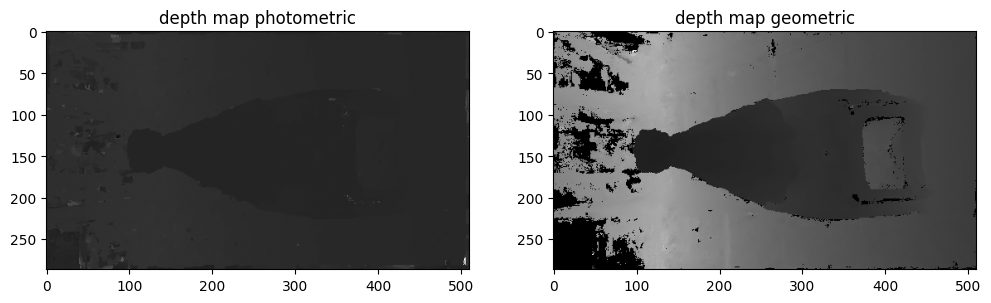

In [49]:
import matplotlib.pyplot as plt
import numpy as np

def read_array(path):
    """
    Taken from https://github.com/colmap/colmap/blob/main/scripts/python/read_write_dense.py
    """
    with open(path, "rb") as fid:
        width, height, channels = np.genfromtxt(
            fid, delimiter="&", max_rows=1, usecols=(0, 1, 2), dtype=int
        )
        fid.seek(0)
        num_delimiter = 0
        byte = fid.read(1)
        while True:
            if byte == b"&":
                num_delimiter += 1
                if num_delimiter >= 3:
                    break
            byte = fid.read(1)
        array = np.fromfile(fid, np.float32)
    array = array.reshape((width, height, channels), order="F")
    return np.transpose(array, (1, 0, 2)).squeeze()

depth_map = read_array(r"..\aparecida\undistorted_8\stereo\depth_maps\20250105_164818.jpg.photometric.bin")
depth_map2 = read_array(r"..\aparecida\undistorted_8\stereo\depth_maps\20250105_164818.jpg.geometric.bin")

# min_depth, max_depth = np.percentile(
#         depth_map, [5, 30]
#     )
# depth_map[depth_map < min_depth] = min_depth
# depth_map[depth_map > max_depth] = max_depth


# Visualize the depth maps.
f, a = plt.subplots(1, 2, figsize=(12, 6))

a[0].imshow(depth_map, cmap='gray')
a[0].set_title("depth map photometric")

a[1].imshow(depth_map2, cmap='gray')
a[1].set_title("depth map geometric")

plt.show()

# 5) Armazenamento de matrizes na memória:

### Diferenças entre row-major e column-major:

Considere um vetor $a_i$ para $i=0,...,8$, copiado para uma matriz A da seguinte maneira:

**Row-major**: $A_{rm} = 
\begin{bmatrix}
a_{0} & a_{1} & a_{2} \\
a_{3} & a_{4} & a_{5} \\
a_{6} & a_{7} & a_{8} 
\end{bmatrix}
$

**Column-major**: $A_{cm} = 
\begin{bmatrix}
a_{0} & a_{3} & a_{6} \\
a_{1} & a_{4} & a_{7} \\
a_{2} & a_{5} & a_{8} \\
\end{bmatrix}
$

Considere agora um vetor $v_i$ para $i=0,...,2$ ao qual deseja-se o produto matricial com $A_{rm}$ e $A_{cm}$:

$A_{rm} \cdot v= 
\begin{bmatrix}
a_{0} & a_{1} & a_{2} \\
a_{3} & a_{4} & a_{5} \\
a_{6} & a_{7} & a_{8} 
\end{bmatrix}
\begin{bmatrix}
v_{0} \\
v_{1} \\
v_{2}
\end{bmatrix} = 
\begin{bmatrix}
a_{0}v_{0} + a_{1}v_{1} + a_{2}v_{2} \\
a_{3}v_{0} + a_{4}v_{1} + a_{5}v_{2} \\
a_{6}v_{0} + a_{7}v_{1} + a_{8}v_{2} \\
\end{bmatrix}
$

$A_{cm} \cdot v= 
\begin{bmatrix}
a_{0} & a_{3} & a_{6} \\
a_{1} & a_{4} & a_{7} \\
a_{2} & a_{5} & a_{8} \\
\end{bmatrix}
\begin{bmatrix}
v_{0} \\
v_{1} \\
v_{2}
\end{bmatrix} = 
\begin{bmatrix}
a_{0}v_{0} + a_{3}v_{1} + a_{6}v_{2} \\
a_{1}v_{0} + a_{4}v_{1} + a_{7}v_{2} \\
a_{2}v_{0} + a_{5}v_{1} + a_{8}v_{2} \\
\end{bmatrix} \ne A_{rm} \cdot v
$

Por serem matrizes quadradas, para retornarem o mesmo resultado, devemos verificar que $A_{cm}^T = A_{rm}$:

$A_{cm}^T \cdot v = 
\begin{bmatrix}
a_{0} & a_{1} & a_{2} \\
a_{3} & a_{4} & a_{5} \\
a_{6} & a_{7} & a_{8} \\
\end{bmatrix} 
\begin{bmatrix}
v_{0} \\ v_{1} \\ v_{2}
\end{bmatrix} = 
\begin{bmatrix}
a_{0}v_{0} + a_{1}v_{1} + a_{2}v_{2} \\
a_{3}v_{0} + a_{4}v_{1} + a_{5}v_{2} \\
a_{6}v_{0} + a_{7}v_{1} + a_{8}v_{2} \\
\end{bmatrix} = A_{rm} \cdot v
$ ou

$(A_{cm}^T \cdot v)^T = v^T \cdot A_{cm} = (A_{rm} \cdot v)^T
$

### Como Pytorch entende vetores linhas e vetores coluna?

In [50]:
import torch

A = torch.tensor([[1, 2, 3, 4], 
                  [5, 6, 7, 8], 
                  [9, 10, 11, 12], 
                  [13, 14, 15, 16]], dtype=torch.float32)

x = torch.tensor([10, 20, 30, 40], dtype=torch.float32) 
print(x.shape) # x é um vetor (4,)

C0 = A @ x
C1 = (x.T @ A.T).T # Pytorch entende que x é um vetor coluna (4,1) 
# Mas isso gera um aviso:
# UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse
# their shape is deprecated and it will throw an error in a future release. 
# Consider `x.mT` to transpose batches of matrices or 
# `x.permute(*torch.arange(x.ndim - 1, -1, -1))` 
# to reverse the dimensions of a tensor.

C2 = (x @ A.T).T   # Pytorch entende que x é um vetor linha  (1,4)

print(C0)
print(C1)
print(C2)

torch.Size([4])
tensor([ 300.,  700., 1100., 1500.])
tensor([ 300.,  700., 1100., 1500.])
tensor([ 300.,  700., 1100., 1500.])
